In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
from utils.ResultsEvaluation import ResultsEvaluation
from utils.graph_plot import *

# Segnature Inference

### Signautres Count

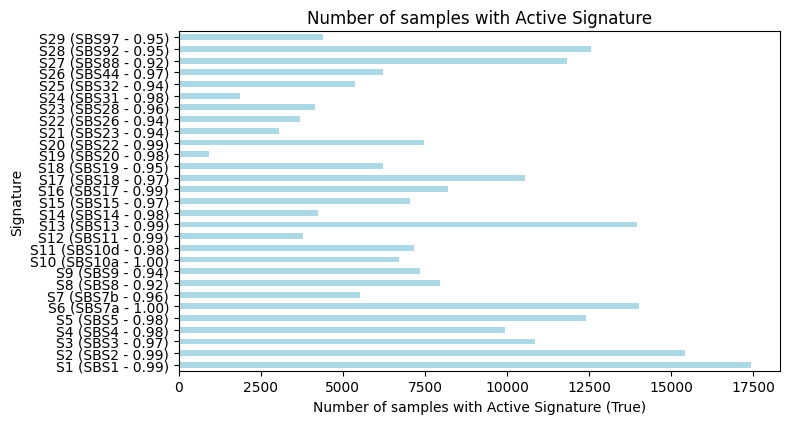

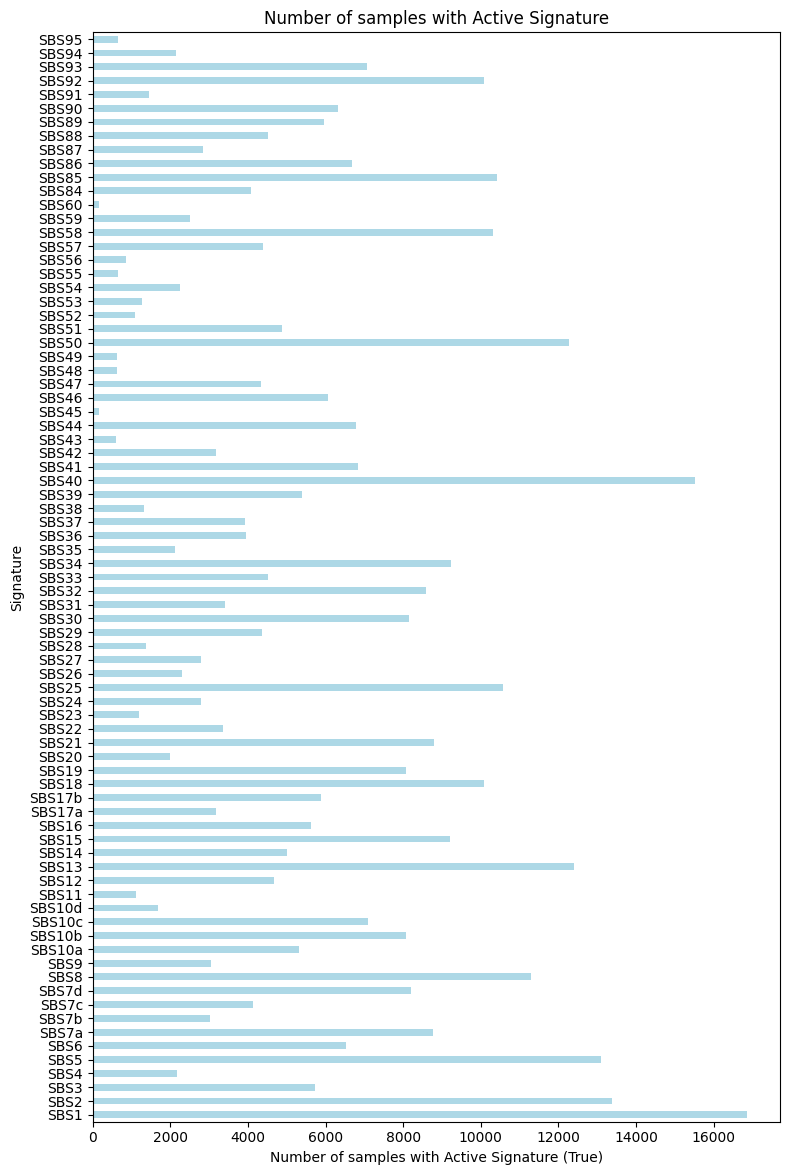

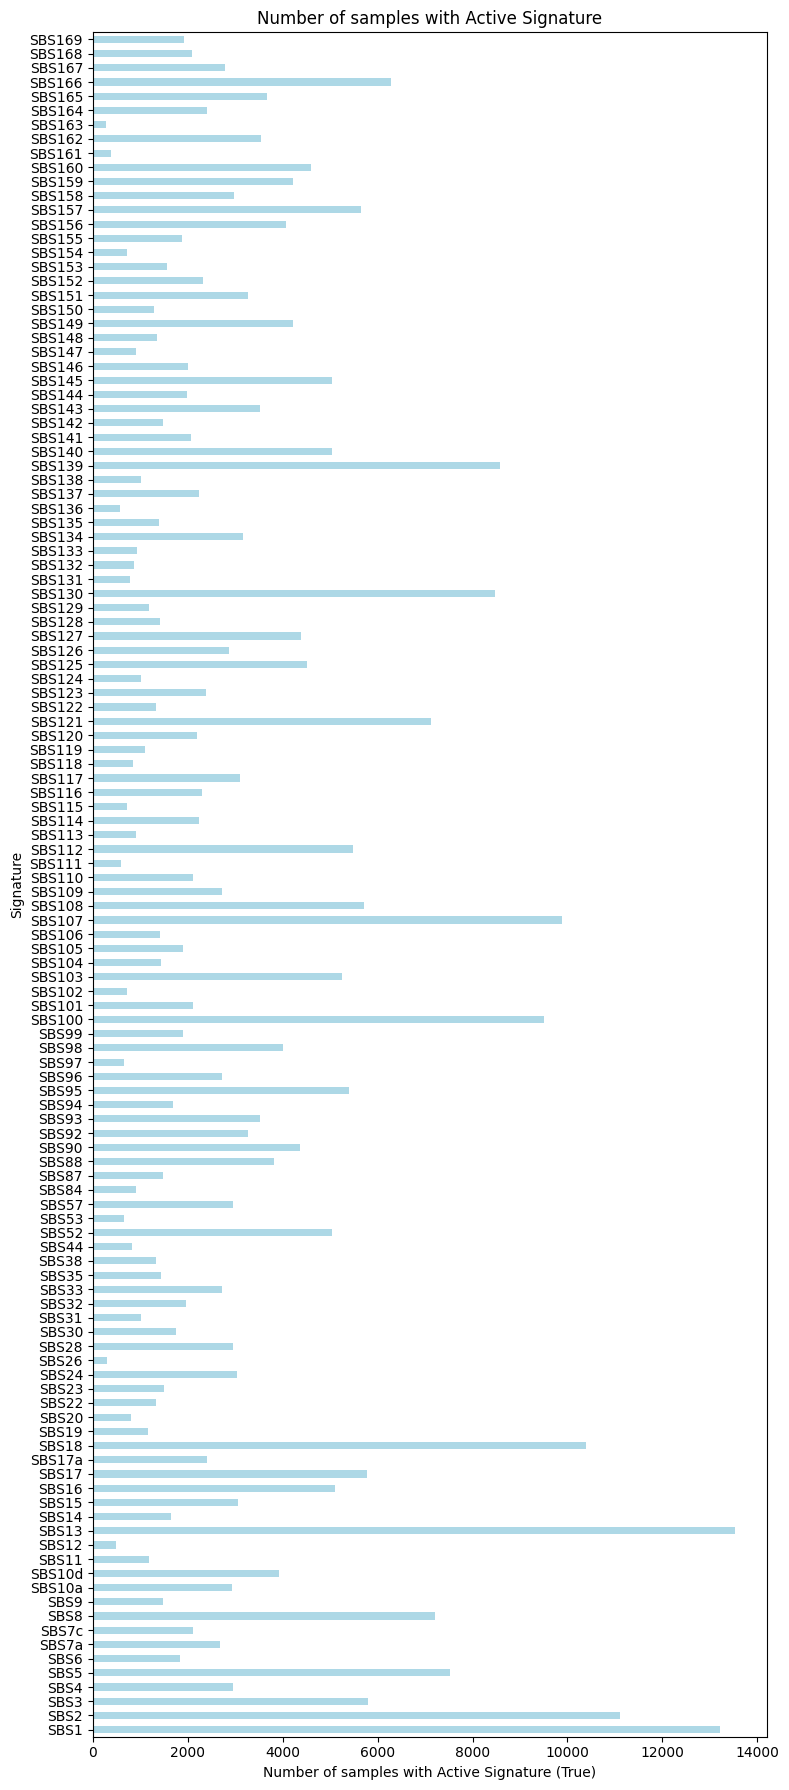

In [2]:
def number_of_sample_per_signature(folder_name):
    signature_gt_path = f'../simulations/ground_truth{folder_name}/bin_exposures.csv'

    signature_gt_df = pd.read_csv(signature_gt_path)
    active_segnature = signature_gt_df.iloc[:, 1:].sum()

    plt.figure(figsize=(8, 0.15*len(active_segnature)))
    active_segnature.plot(kind='barh', color='lightblue')
    plt.ylabel('Signature')
    plt.xlabel('Number of samples with Active Signature (True)')
    plt.title('Number of samples with Active Signature')
    plt.tight_layout()
    plt.show()
    
    
gt_labels = ['','_cosmic','_reference']
for label in gt_labels:
    number_of_sample_per_signature(label)


## Analysis the Ensamble of Models

The graphs show the performance of the various models that compose the enamble, for reference I showed the final accuracy highlited as **total_accuracy**, each graph is relative to a sample

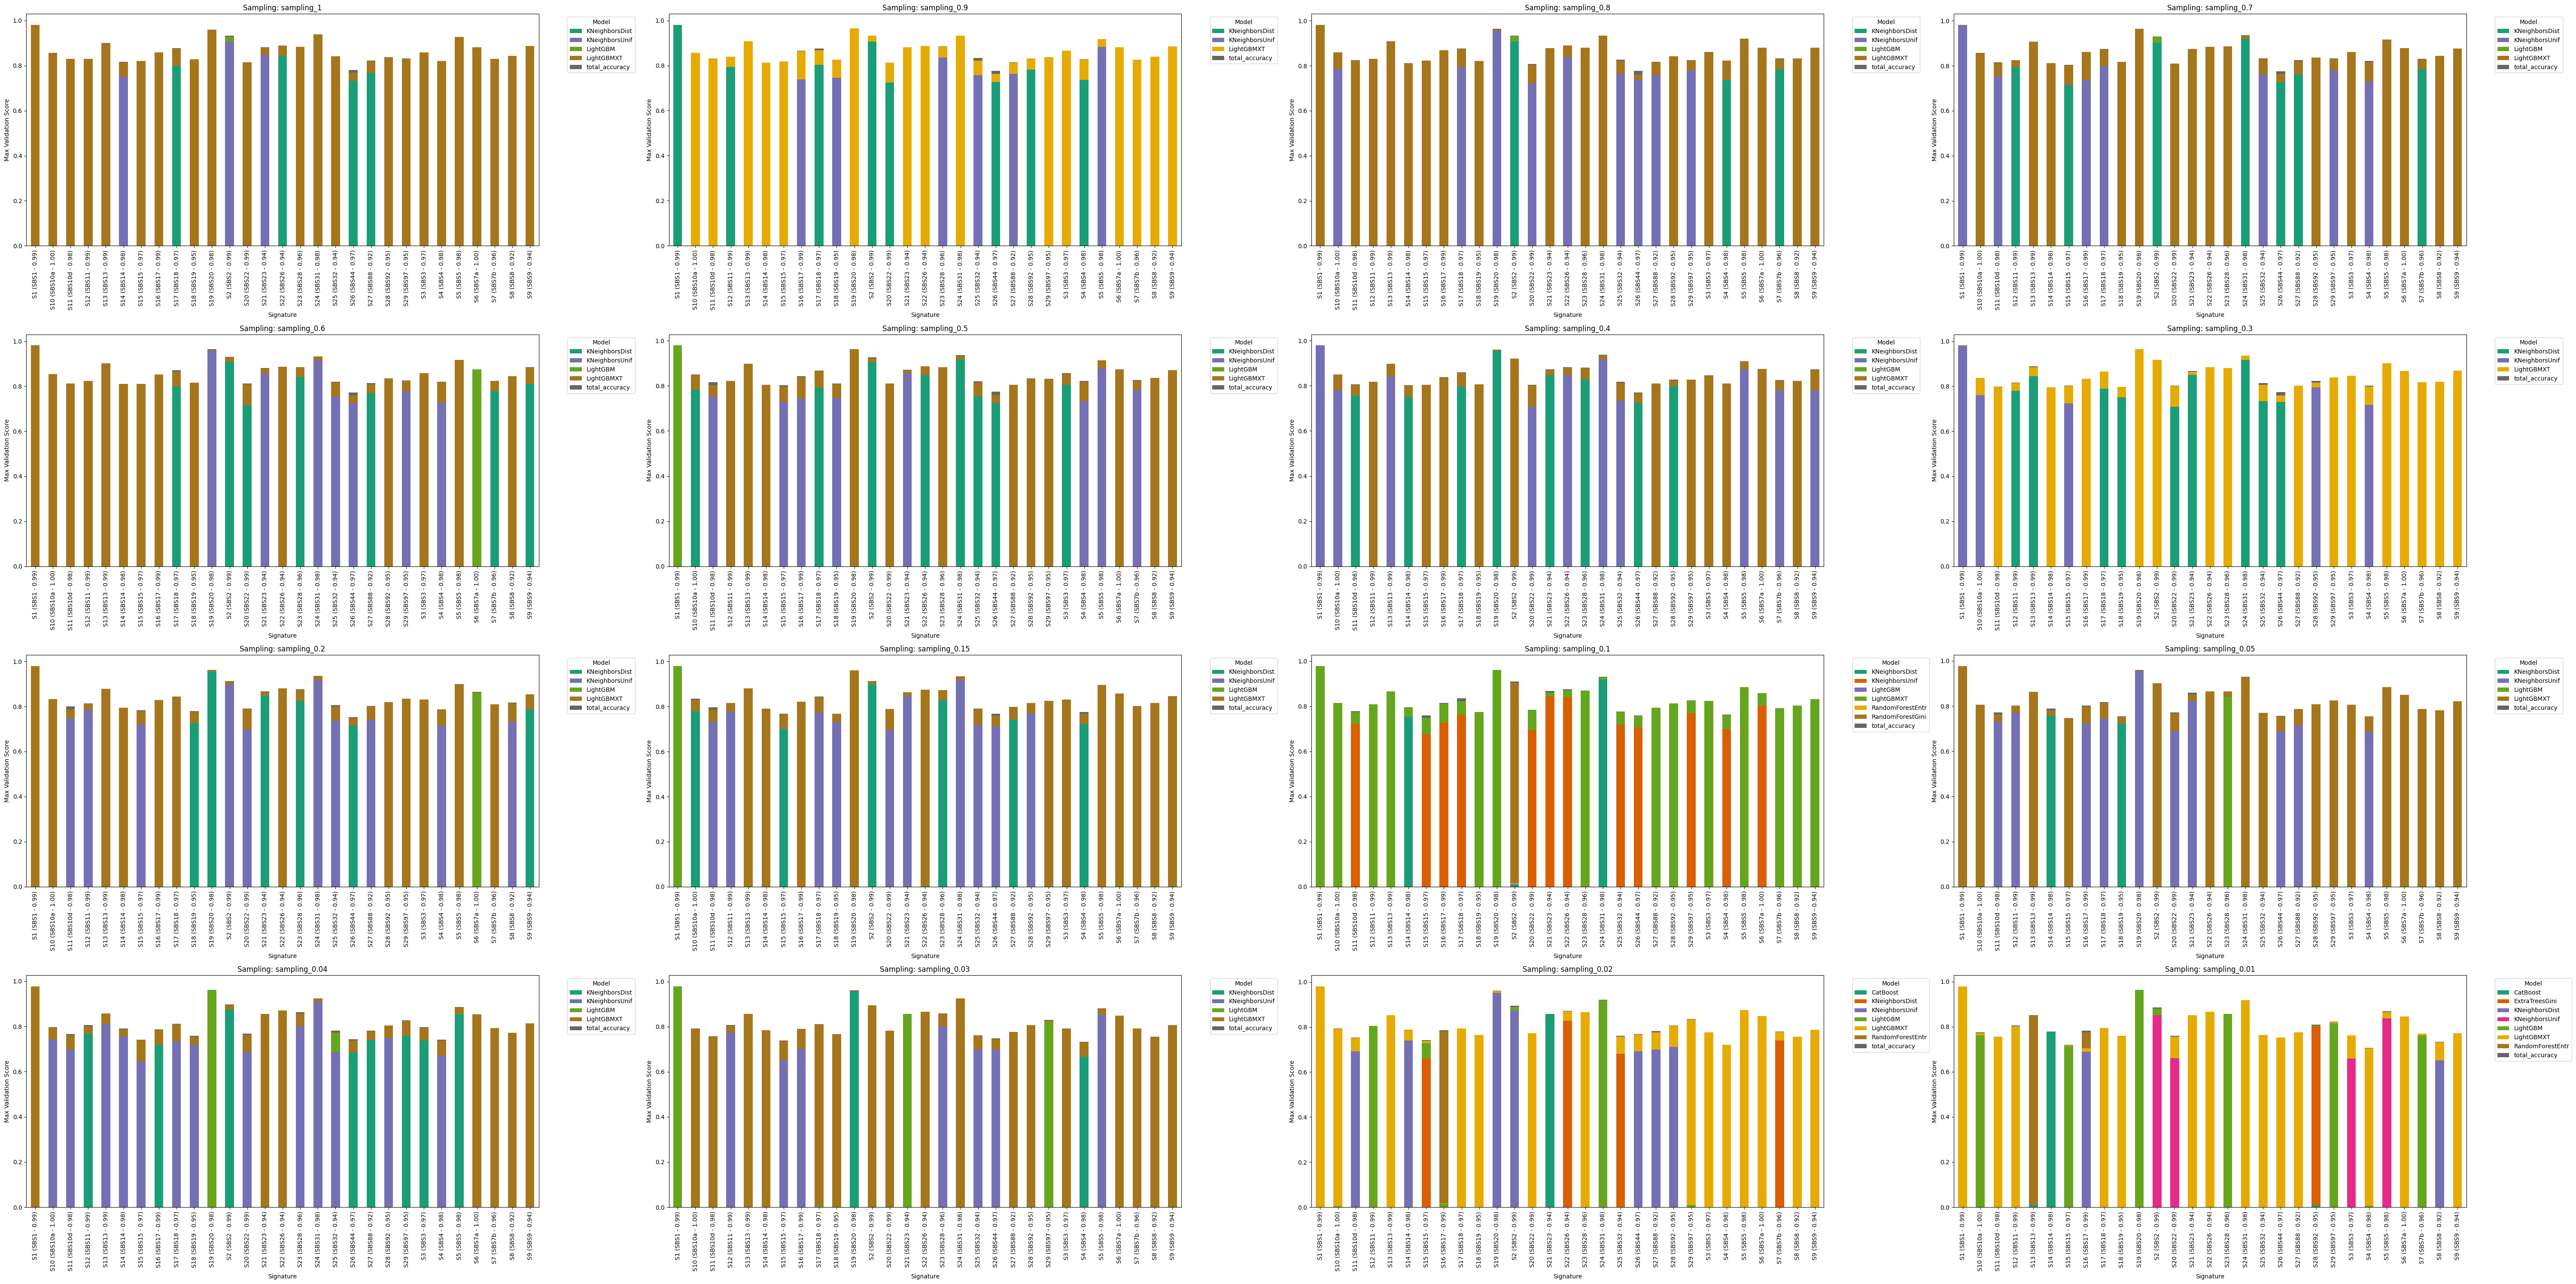

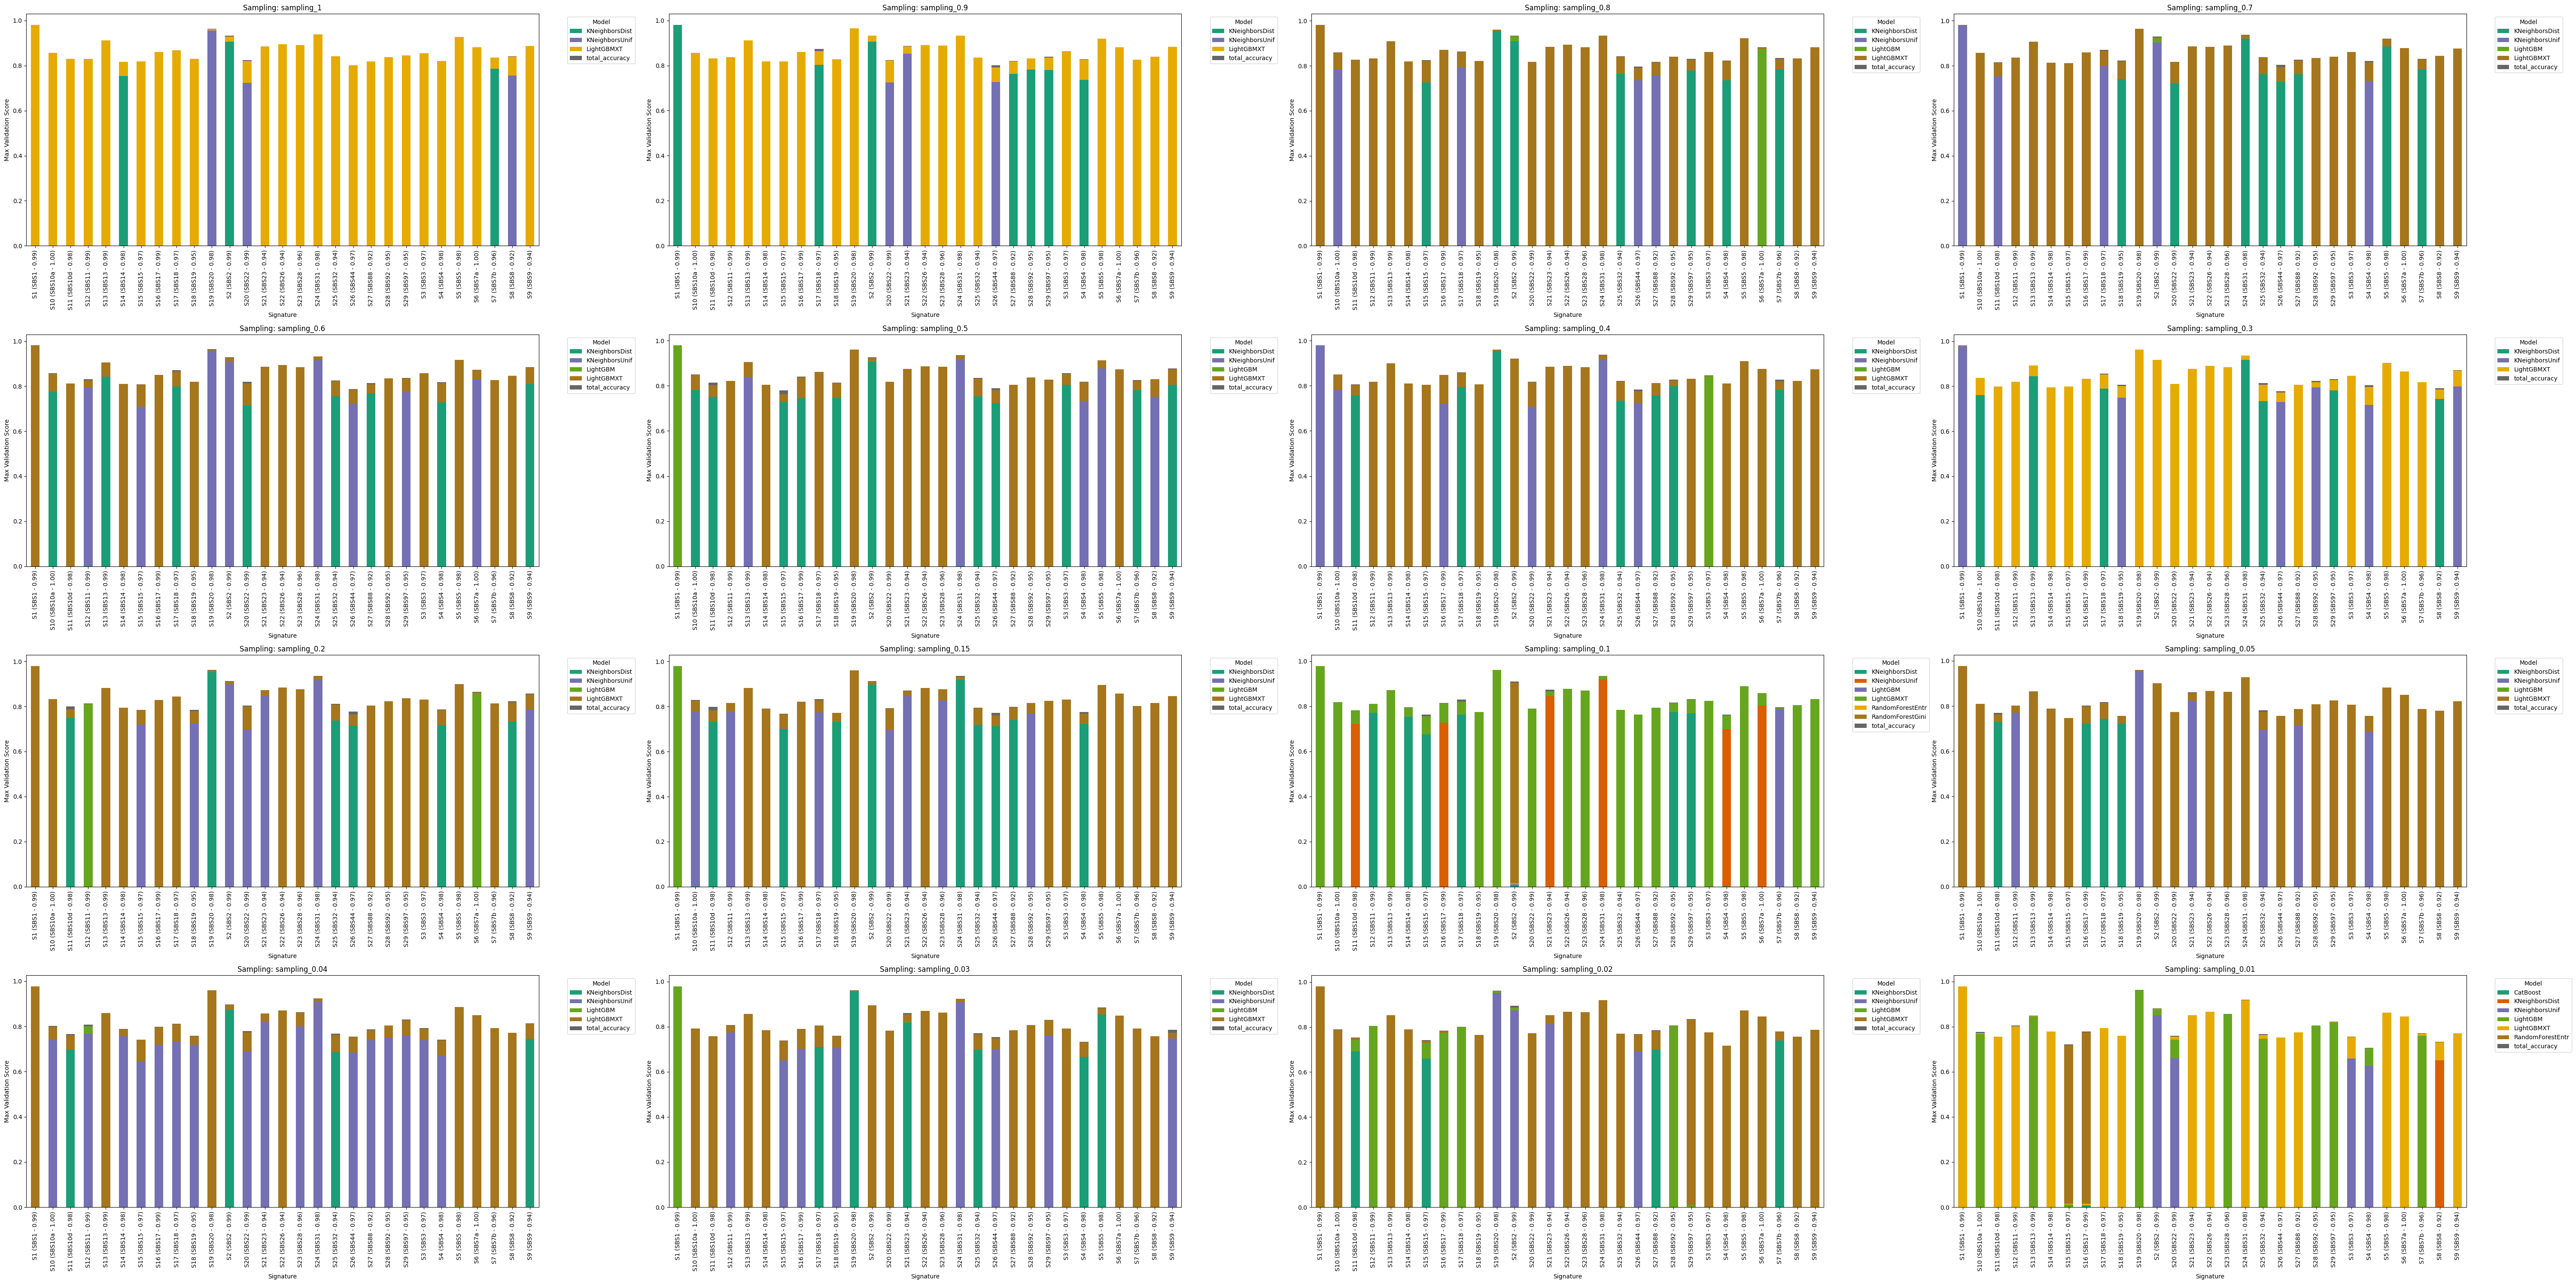

In [3]:
correlated_ensamble = ResultsEvaluation('./tries/default_correlated_evaluations')
uncorrelated_ensamble = ResultsEvaluation('./tries/default_non_correlated_evaluations')
plot_evaluation_ensamble(correlated_ensamble)
plot_evaluation_ensamble(uncorrelated_ensamble)

## Which model is the best?

Tha table show the various model and how many times the specific model has been positioned in the various ensamble (377 menas that the LightGBMXT was first in 377 ensambles)

In [4]:
from collections import defaultdict

def best_models_and_positions(rs):
    run1 = rs.evaluations_df['run_1']
    position_counts = defaultdict(lambda: defaultdict(int))

    for sampling in run1.values():
        for sig in sampling:
            for pos, model in enumerate(sig['ensemble_models'], start=1):
                position_counts[pos][model] += 1

    # Convertiamo in DataFrame
    df = pd.DataFrame(position_counts).T.fillna(0).astype(int)
    df.index.name = 'Position'
    df.columns.name = 'Model'
    return df

In [5]:
correlated_df = best_models_and_positions(correlated_ensamble)
uncorrelated_df = best_models_and_positions(uncorrelated_ensamble)
uncorrelated_df.style

Model,LightGBMXT,KNeighborsDist,LightGBM,KNeighborsUnif,RandomForestGini,CatBoost,RandomForestEntr
Position,,,,,,,
1,337,116,9,1,1,0,0
2,114,1,25,75,0,3,0
3,0,0,6,43,0,0,2
4,0,0,0,1,0,0,1


### Confront between the best model, the ensamble and the non correlated version

In [6]:
rss_tries = []
def_corr_rs = ResultsEvaluation('tries/default_correlated_evaluations')
def_uncorr_rs = ResultsEvaluation('tries/default_non_correlated_evaluations')
def_light = ResultsEvaluation('tries/default_light_evaluations')

files_tries = ['Correlated', 'Uncorrelated', 'LightGBMXT']

rss_tries = [def_uncorr_rs, def_corr_rs, def_light]

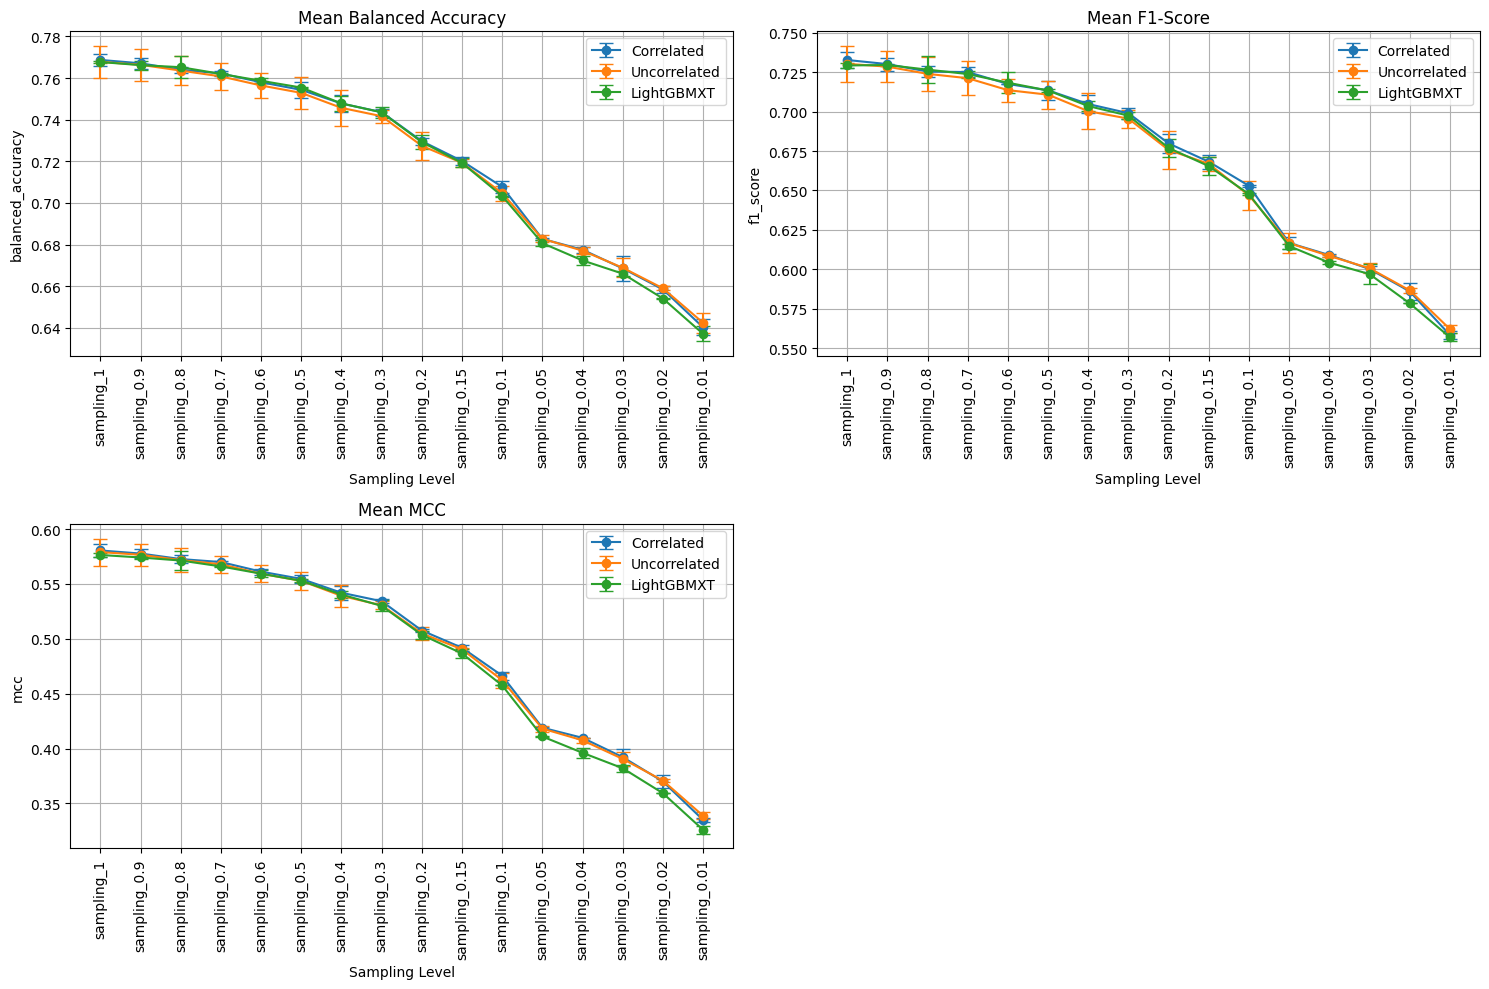

In [7]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.title("Mean Balanced Accuracy")
for rs, name in zip(rss_tries, files_tries):
    plot_per_run_metric(rs, attr_name='per_run_balanced_accuracy', metric_name=name)

plt.subplot(2,2,2)
plt.title('Mean F1-Score')
for rs, name in zip(rss_tries, files_tries):
    plot_per_run_metric(rs, attr_name='per_run_f1_score', metric_name=name)

plt.subplot(2,2,3)
plt.title('Mean MCC')
for rs, name in zip(rss_tries, files_tries):
    plot_per_run_metric(rs, attr_name='per_run_mcc', metric_name=name)

### Difference in the settings

*Hypotheses in the Friedman test*

1. Assumption: One group that is measured on three or more different occasions.

2. Assumption: Group is a random sample from the population.

3. Assumption: Your dependent variable should be measured at the ordinal or continuous level. Examples of ordinal variables include Likert scales (e.g., a 7-point scale from strongly agree through to strongly disagree), amongst other ways of ranking categories (e.g., a 5-point scale explaining how much a customer liked a product, ranging from "Not very much" to "Yes, a lot"). Examples of continuous variables include revision time (measured in hours), intelligence (measured using IQ score), **exam performance (measured from 0 to 100)**, weight (measured in kg), and so forth. You can learn more about ordinal and continuous variables in our article: Types of Variable.

4. Assumption: Samples do NOT need to be normally distributed.

- Null hypothesis: there is no significant difference between the settings of the ensamble.
- Alternative hypothesis: there is a significant difference between the settings of the ensamble.

In [8]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

df = pd.DataFrame(columns = files_tries)
i = 0
for rs in rss_tries:
    df[files_tries[i]]= np.mean(np.mean(np.array(rs.per_run_balanced_accuracy), axis=0),axis=1)
    i += 1
stat, p = friedmanchisquare(df[files_tries[0]], df[files_tries[1]], df[files_tries[2]])
print(f"Friedman chi2 = {stat:.4f}, p = {p:.4f}")

posthoc = sp.posthoc_conover_friedman(df.values, p_adjust='holm')

posthoc.index = df.columns
posthoc.columns = df.columns

print(posthoc)

Friedman chi2 = 6.1250, p = 0.0468
              Correlated  Uncorrelated  LightGBMXT
Correlated      1.000000      0.089660    0.057657
Uncorrelated    0.089660      1.000000    0.706113
LightGBMXT      0.057657      0.706113    1.000000


### Heat map of the averaged signature

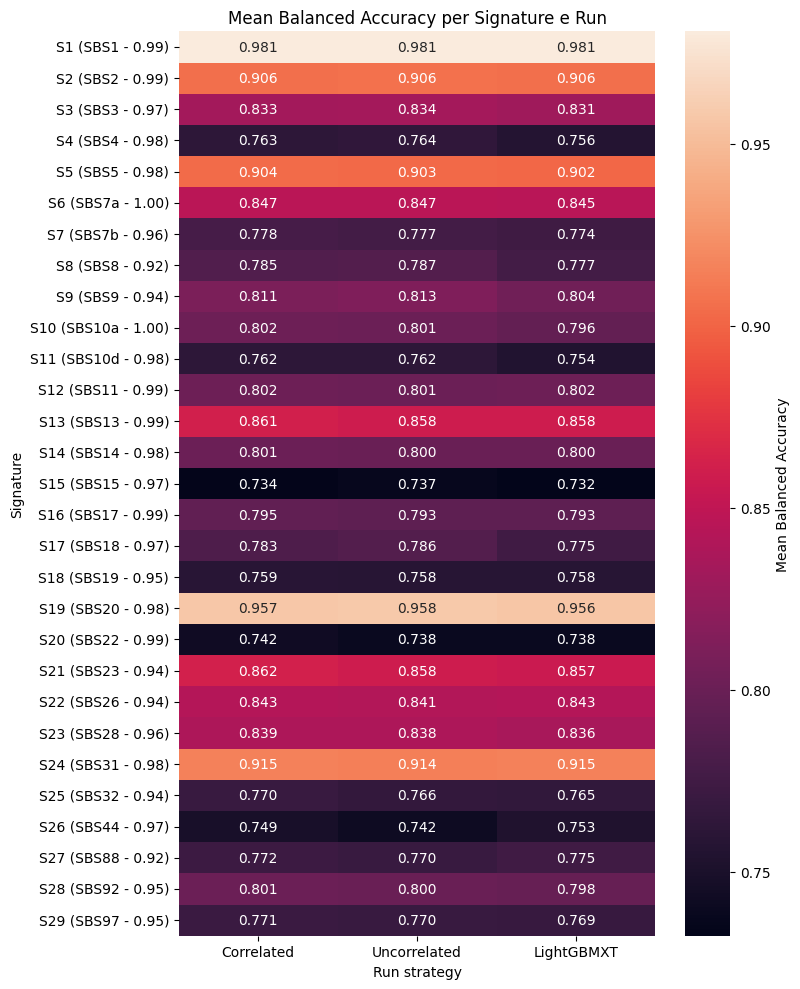

In [9]:
plot_signature_heatmap(rss_tries, files_tries)

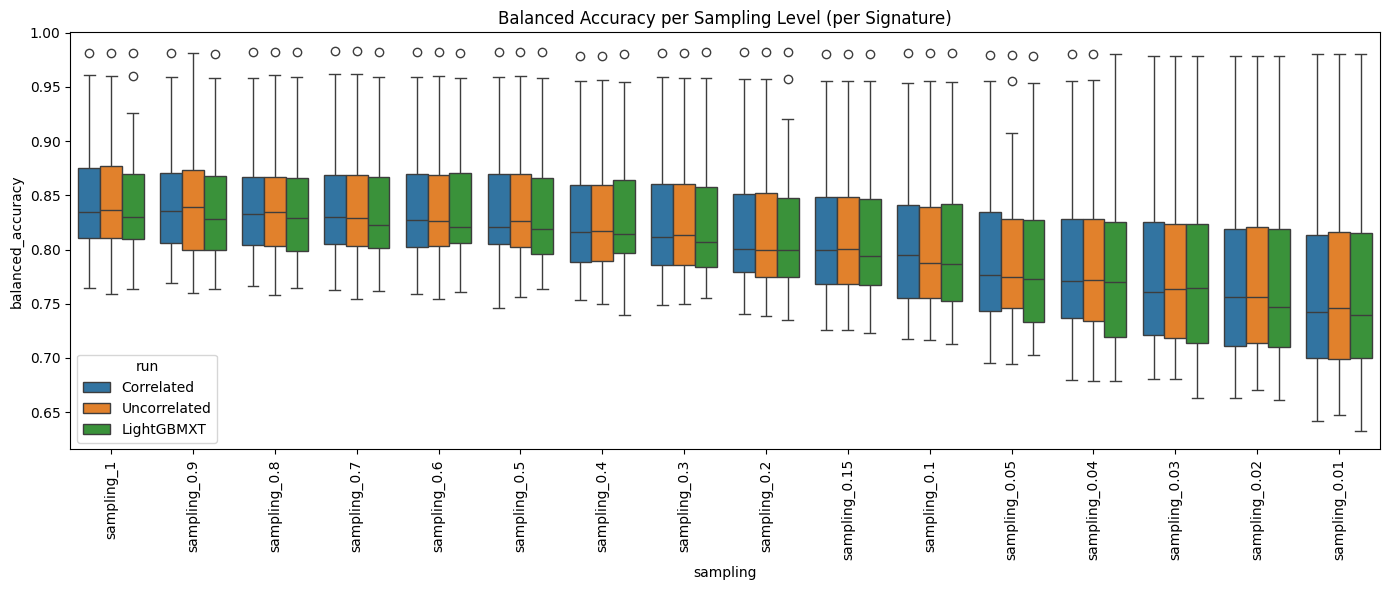

In [10]:
plot_boxplot_accuracy_by_sampling(rss_tries, files_tries)

## Time evaluations

This numbers refear to the average fit time for each hyperparameter configuration of every ensamble 

In [11]:
for rs, f in zip(rss_tries, files_tries):
    print(f'{f}: {np.mean(np.mean(np.sum(rs.per_run_fit_time, axis=2), axis=1), axis = 0)}')


Correlated: 97.91481442004442
Uncorrelated: 97.48097892850637
LightGBMXT: 1.3575311675667763


## Best Model Evaluations

In [12]:
rss = []
files = ['default_evaluations','cosmic_evaluations', 'reference_evaluations']
for f in files:
    rss.append(ResultsEvaluation(f))
for f, rs in zip (files, rss):
    print(f'{f} : {len(rs.run_labels)} runs')

default_evaluations : 72 runs
cosmic_evaluations : 31 runs
reference_evaluations : 18 runs


### Heat Map of the Accuracy for evey signature and every sample (Averaged Across Runs)

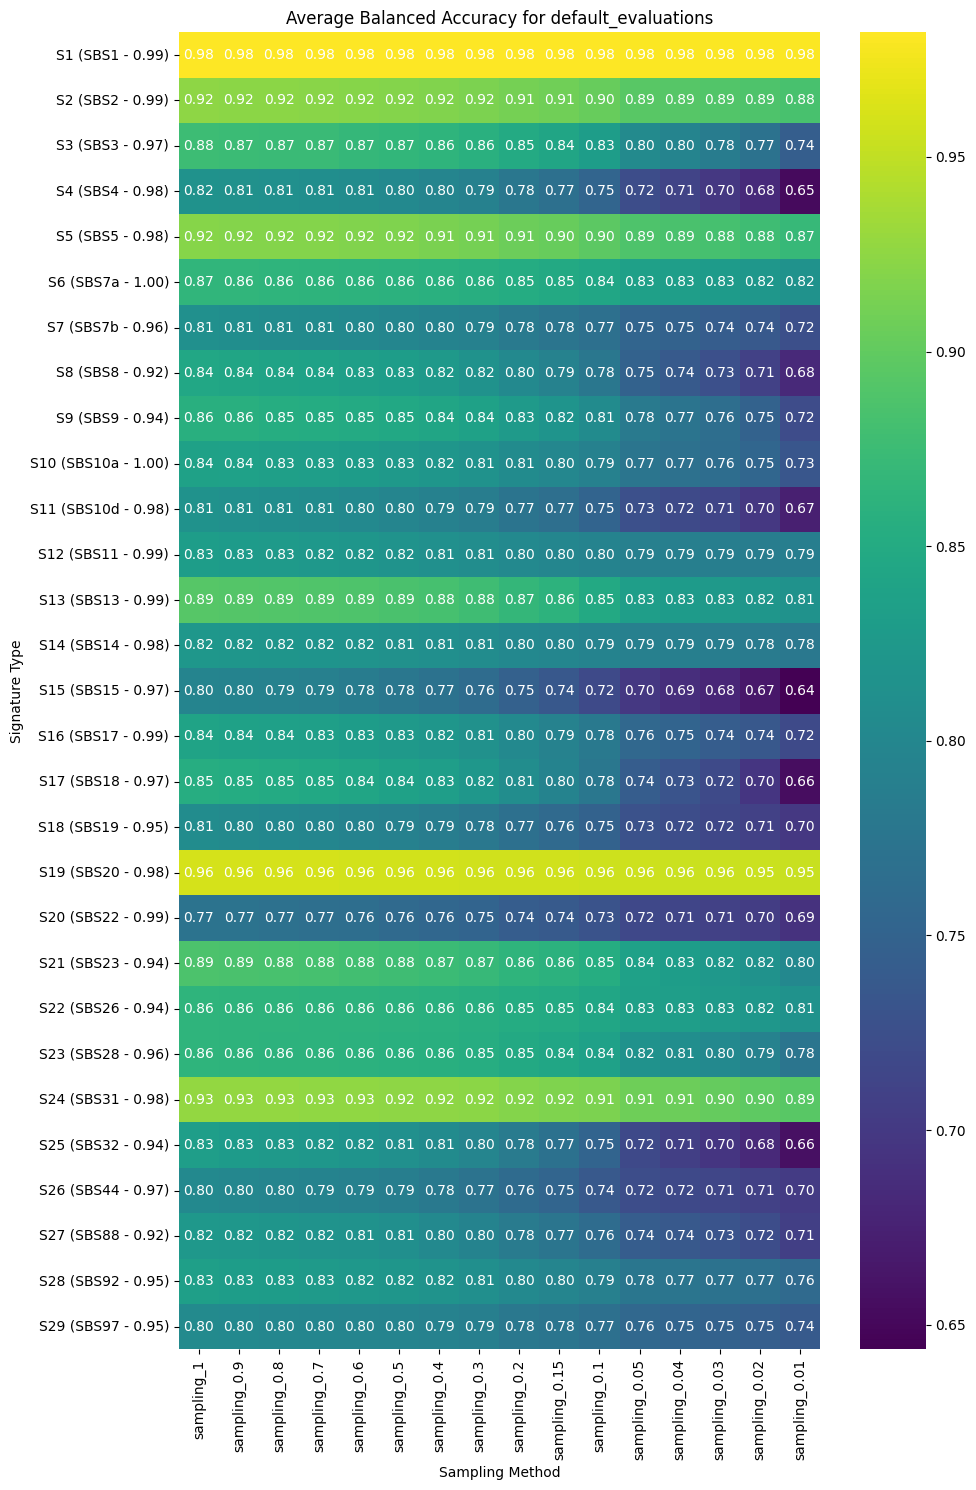

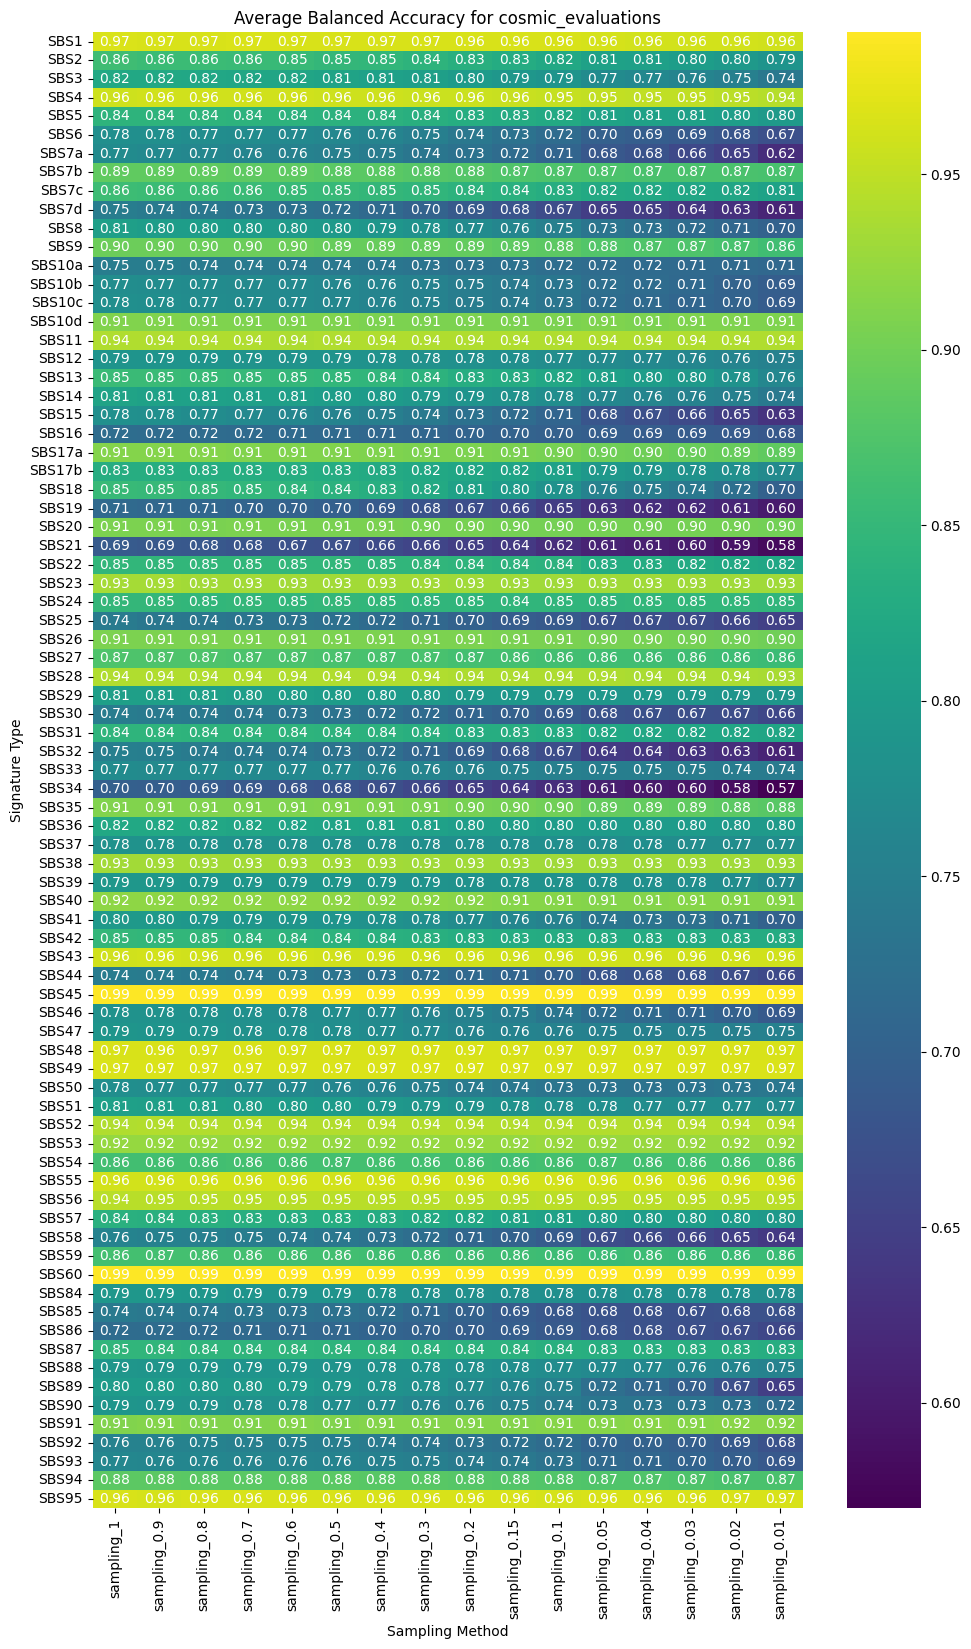

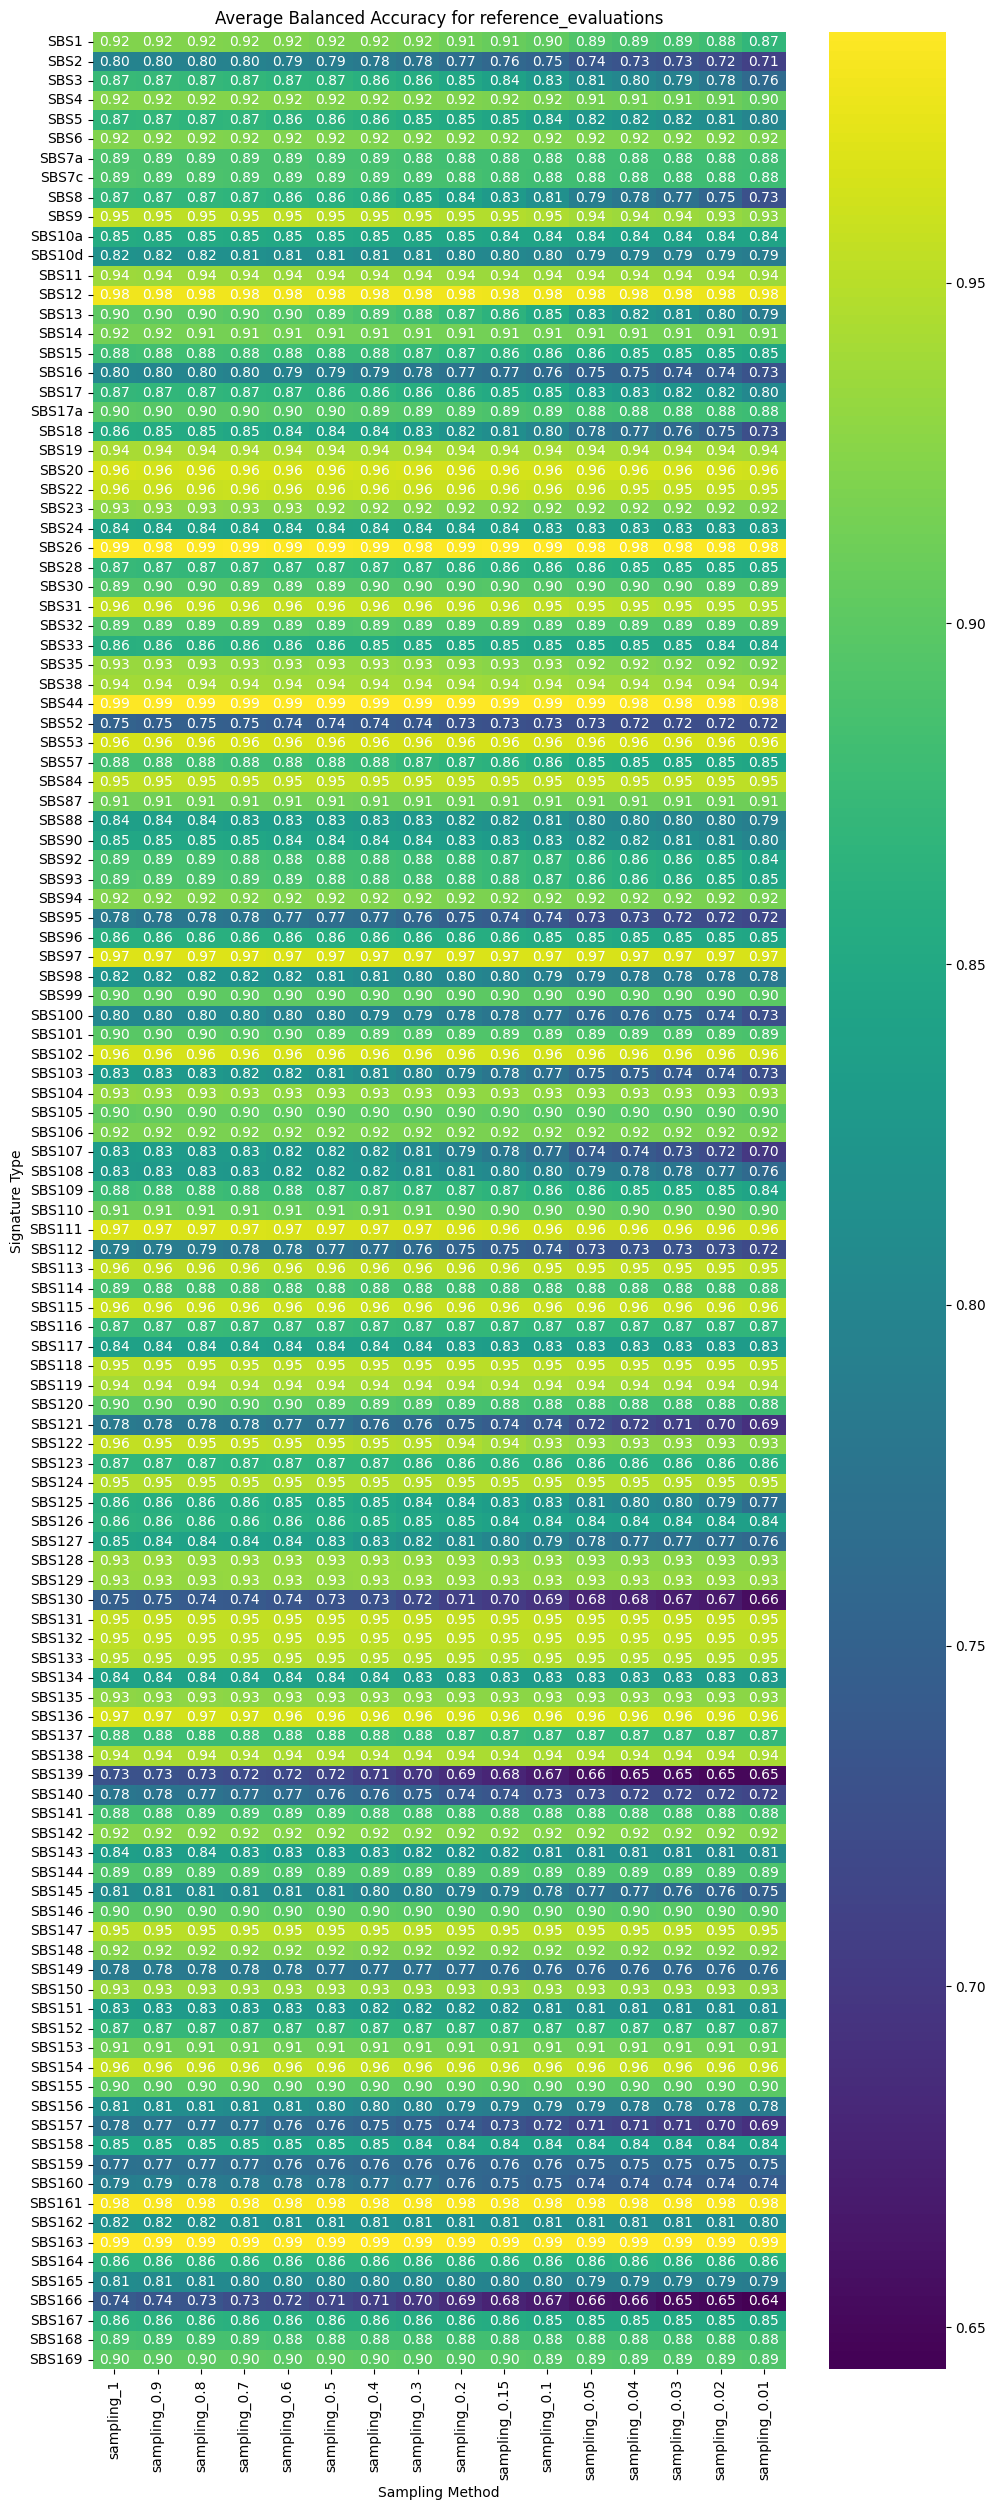

In [13]:
for rs, f in zip(rss, files):
    heat_map(rs, f)

### Accuracy of every Signature at the changing of the sample size

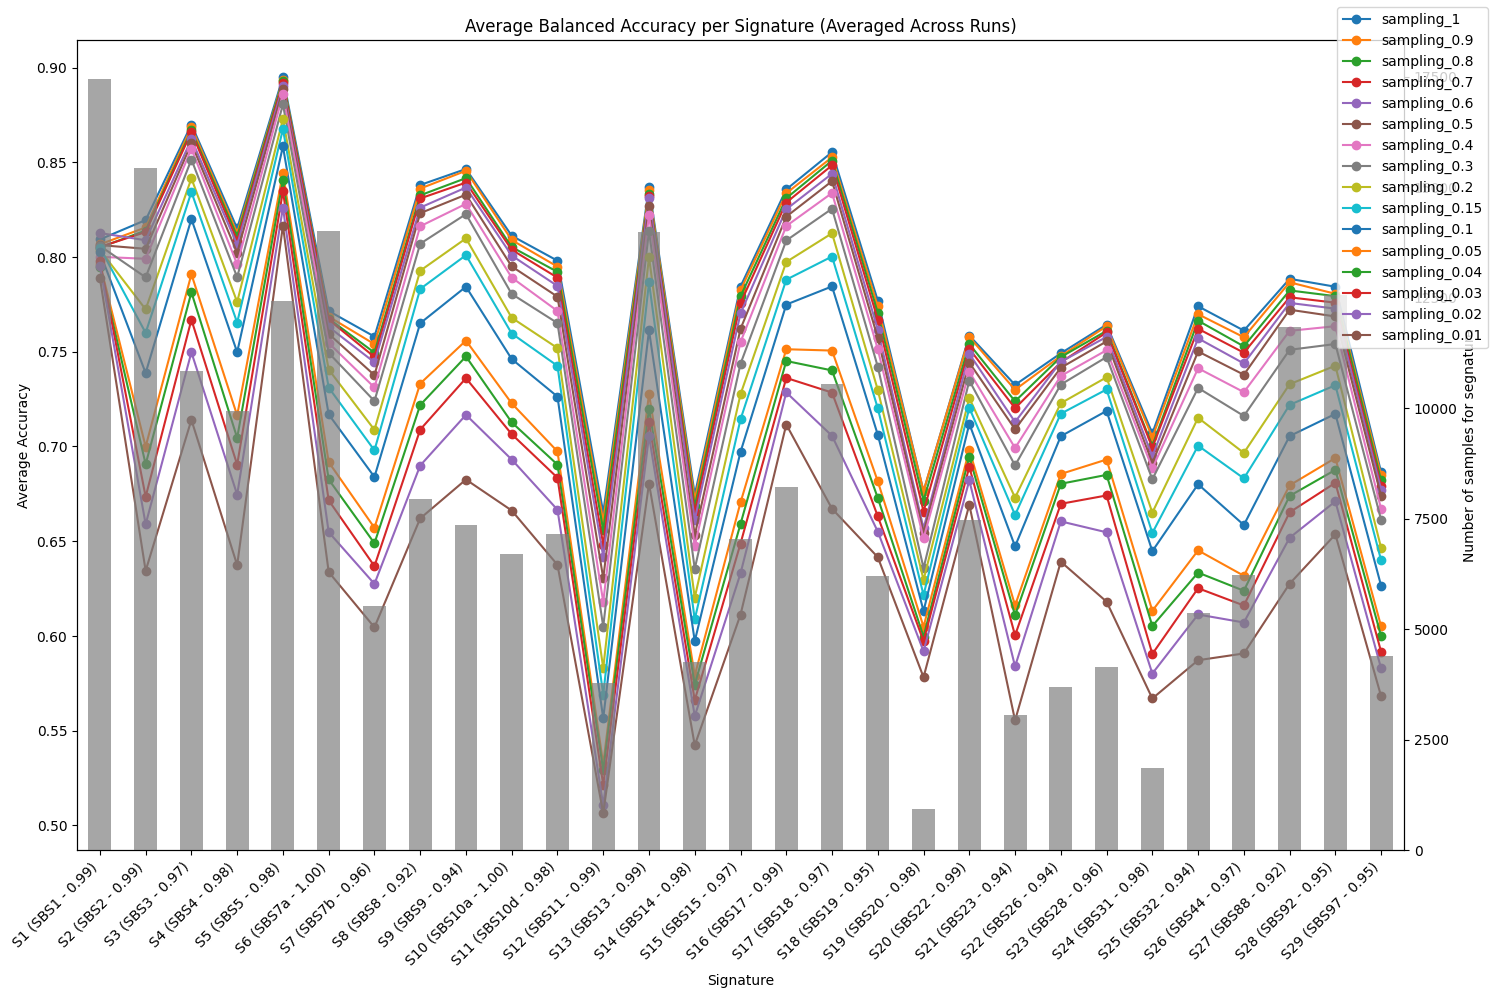

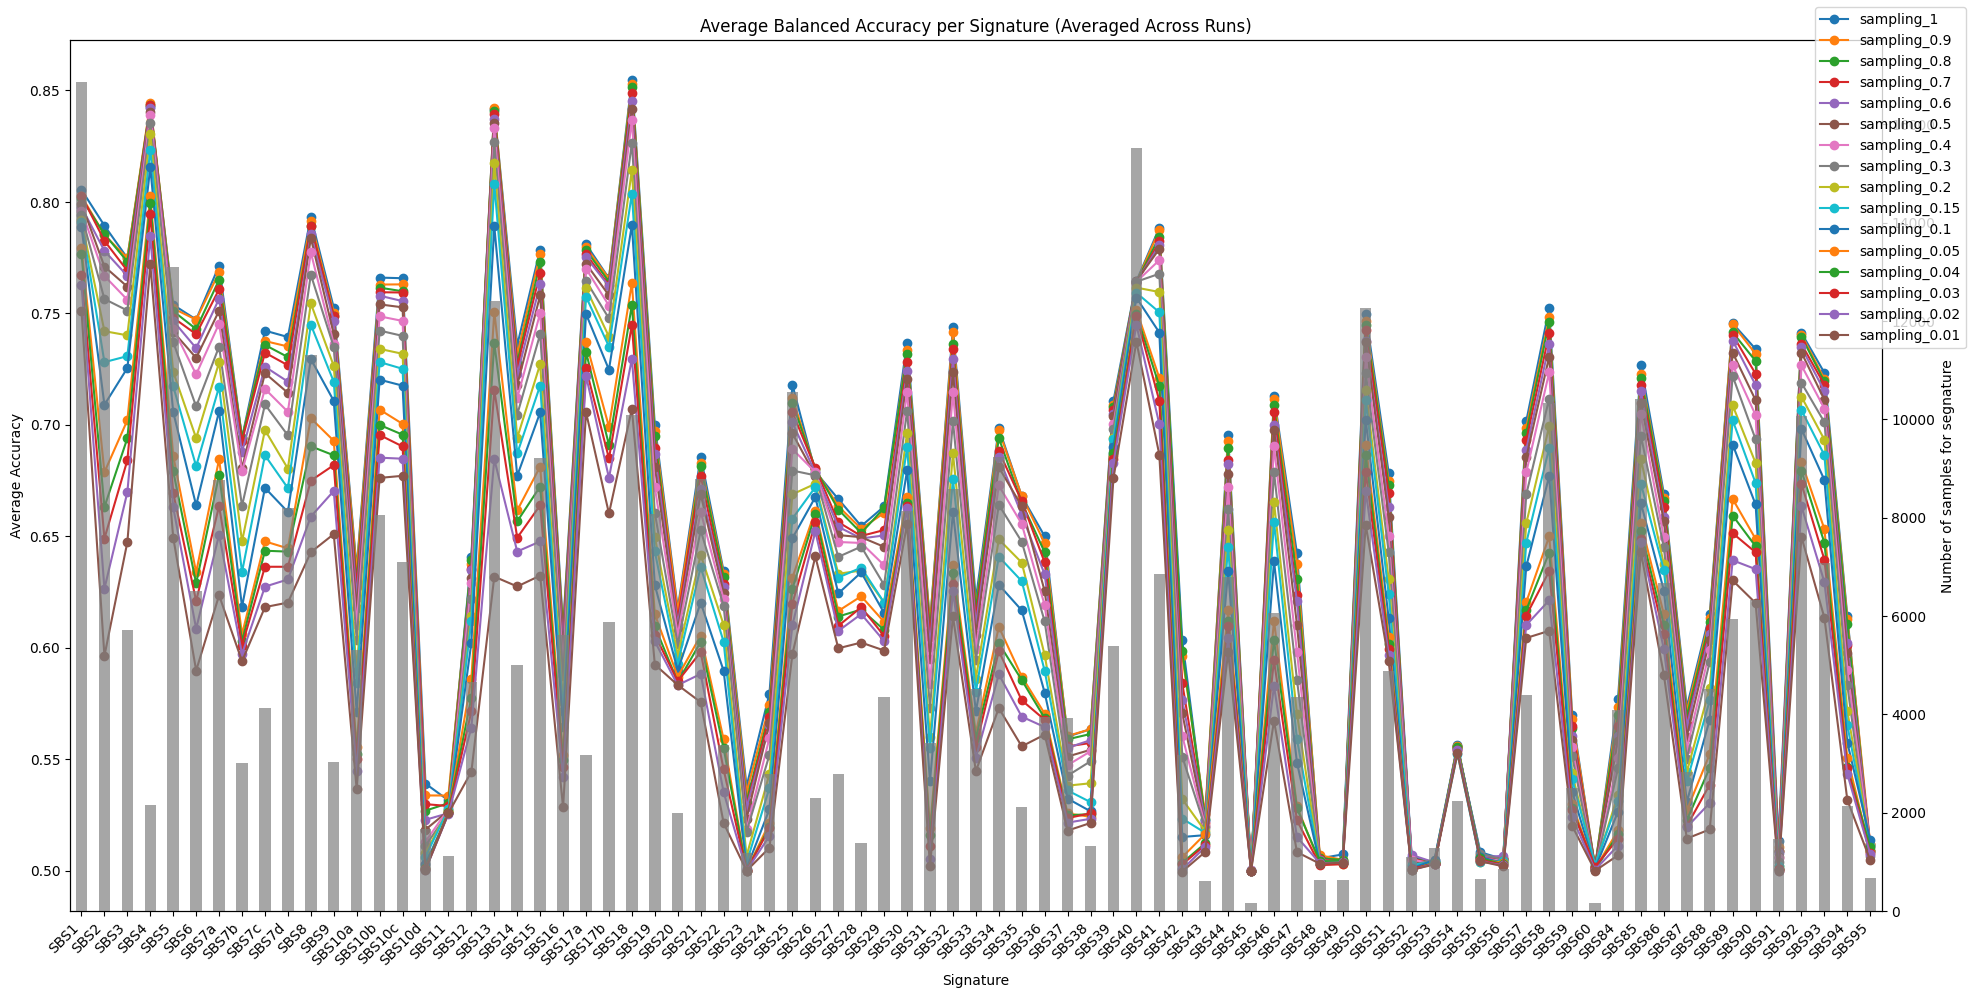

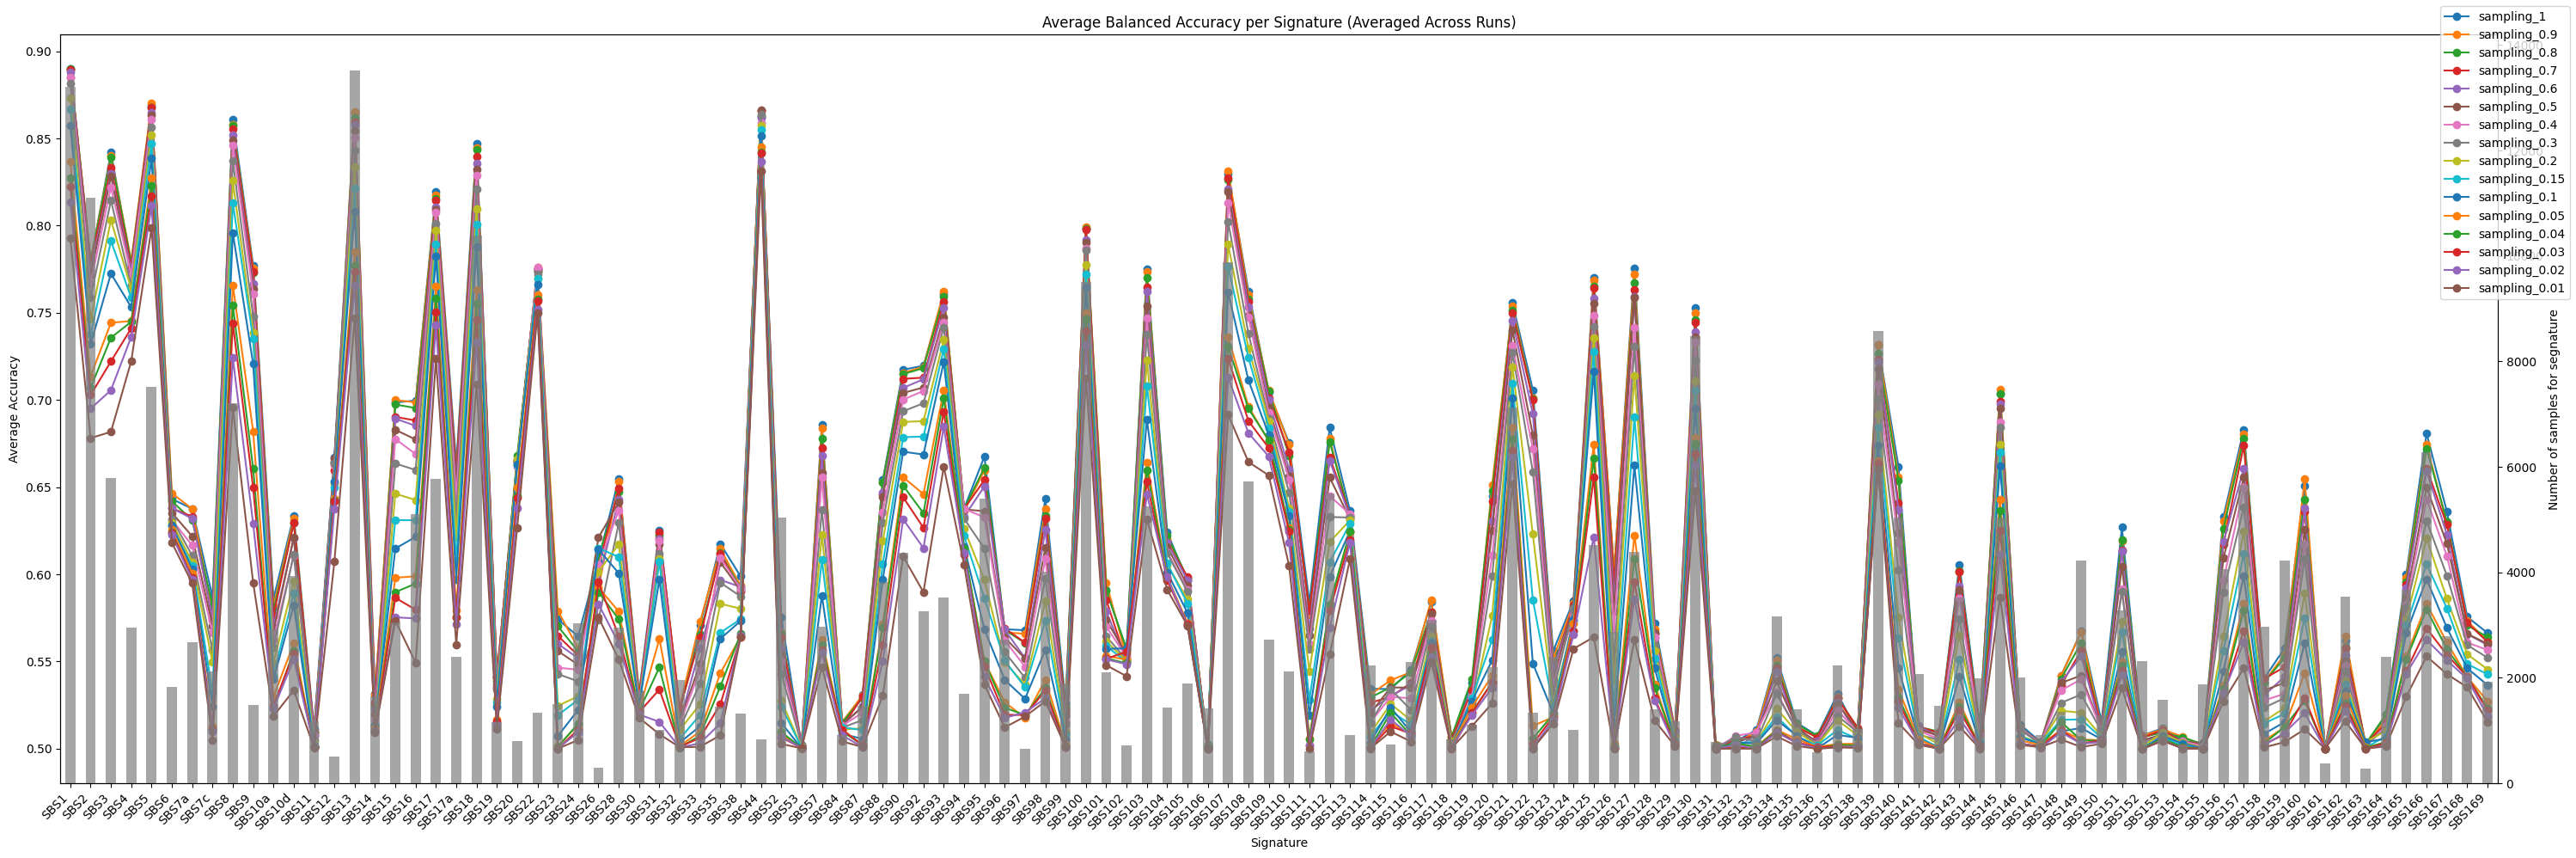

In [14]:
for rs,gt_label in zip(rss, gt_labels):
    plot_all_signature_all_sampling_graph(rs, folder_name=gt_label, bins=True)

### Correlation between the number of samples and the balanced Accuracy

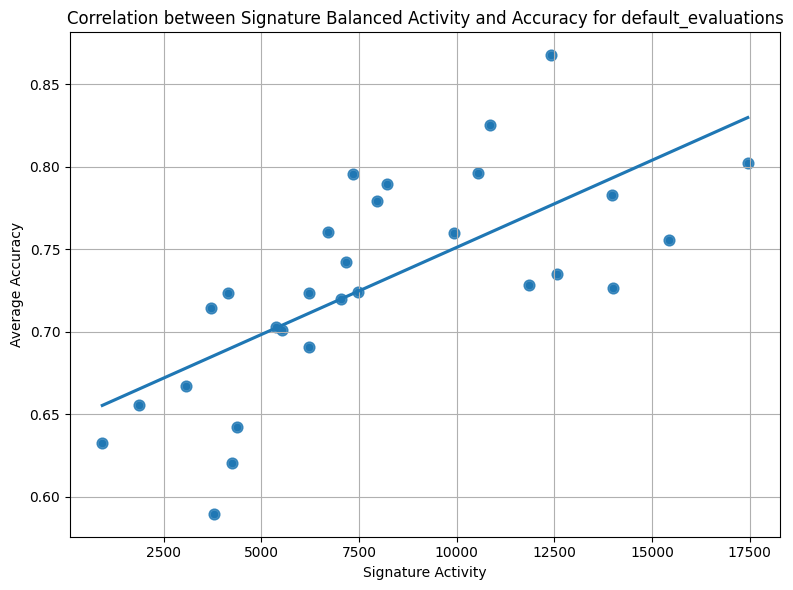

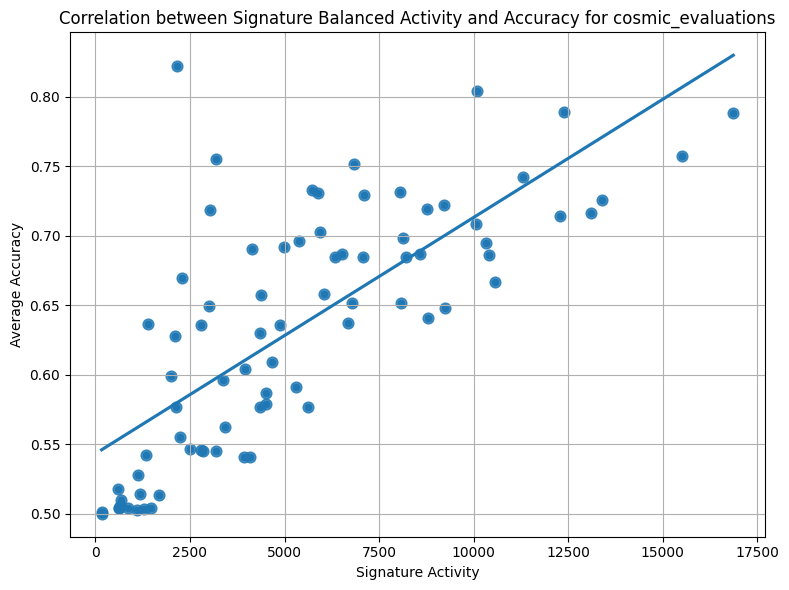

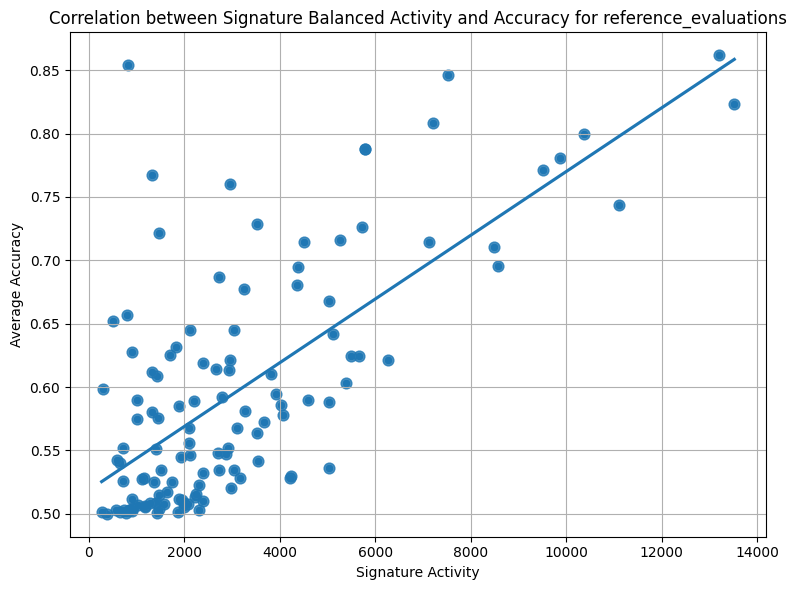

In [15]:
for rs, gt_type, f in zip(rss, gt_labels, files):
    plot_correlation_scatter_plot(rs, 'per_run_balanced_accuracy', gt_type, f)

### Standar deviation of the signature per each sample across all runs

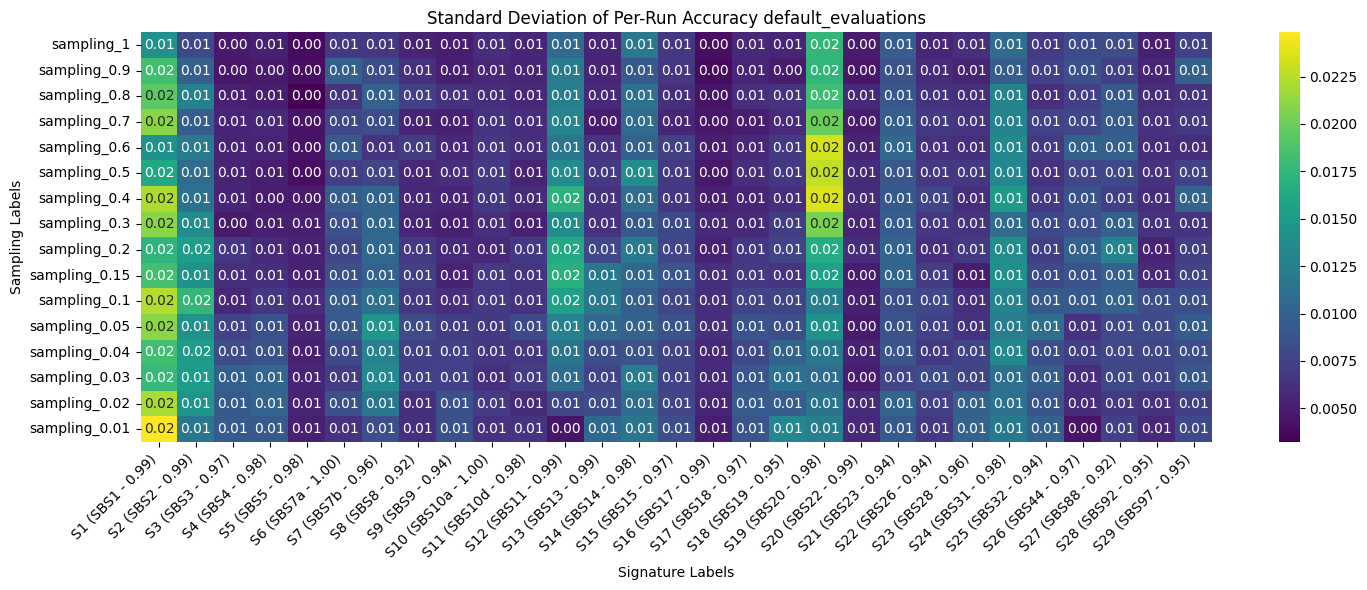

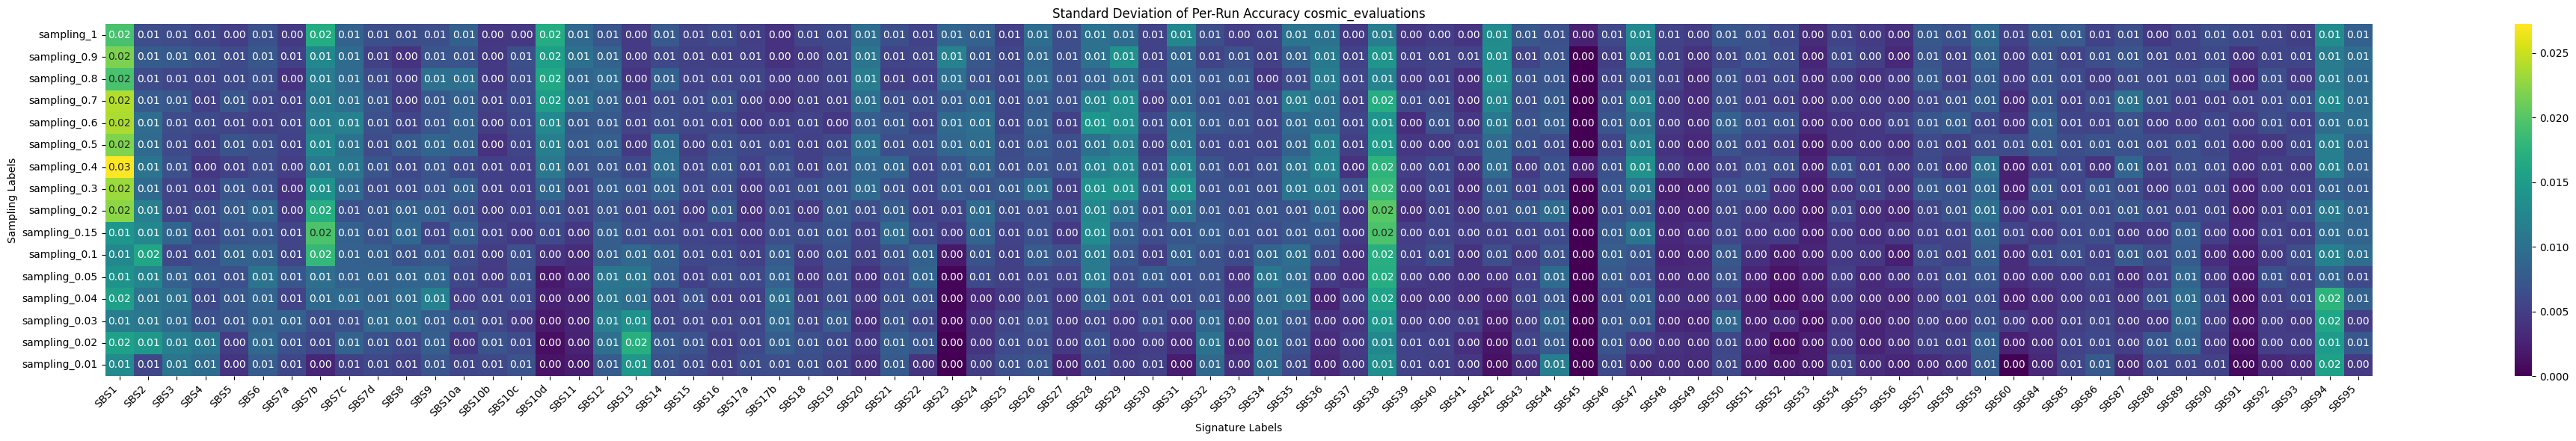

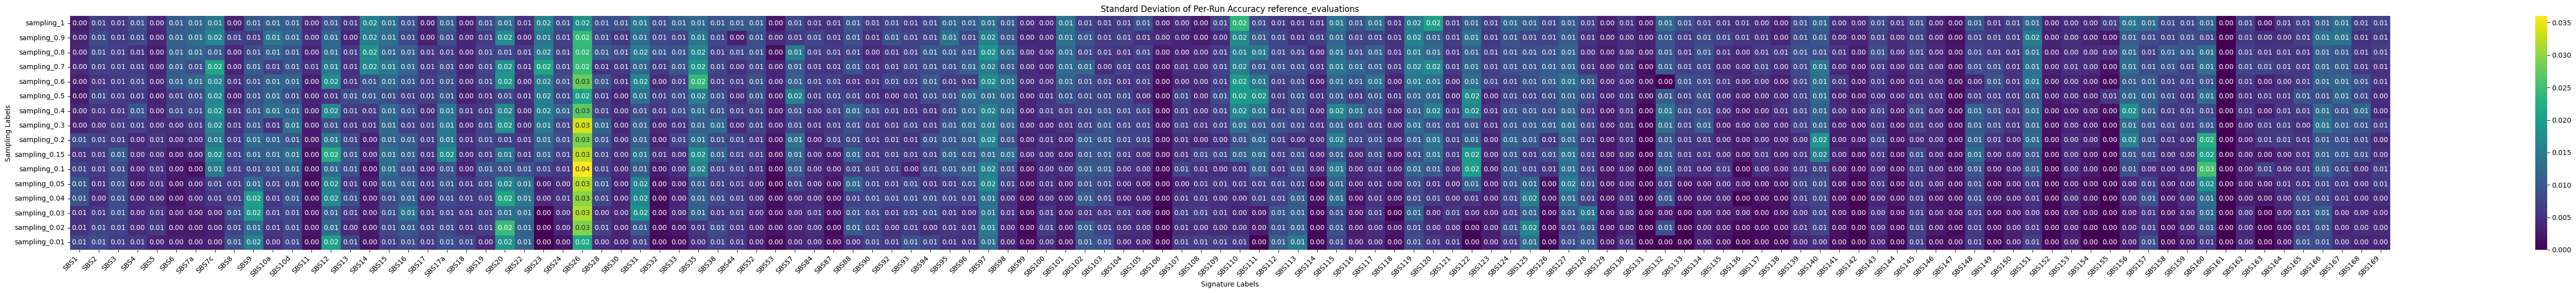

In [16]:
for rs, f in zip(rss, files):
    plot_standard_deviations(rs, f)

### Average Accuracy, F1-Score and MCC per sampling size for the three ground truths

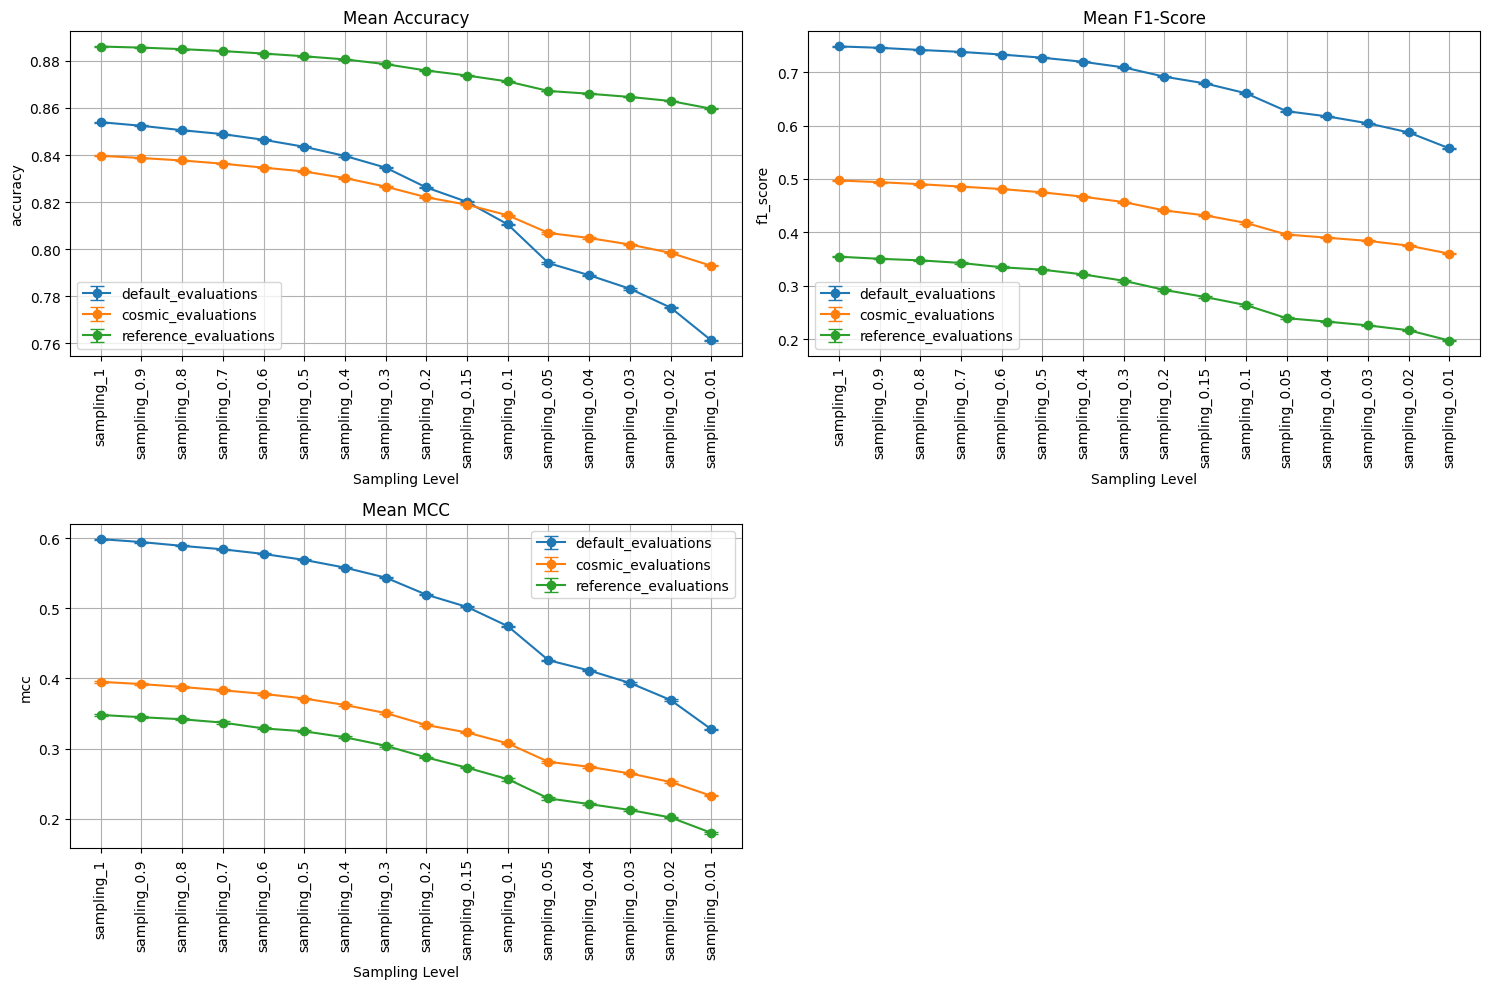

In [17]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.title("Mean Accuracy")
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_accuracy', metric_name=name)

plt.subplot(2,2,2)
plt.title('Mean F1-Score')
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_f1_score', metric_name=name)

plt.subplot(2,2,3)
plt.title('Mean MCC')
for rs, name in zip(rss, files):
    plot_per_run_metric(rs, attr_name='per_run_mcc', metric_name=name)

### Box-plot

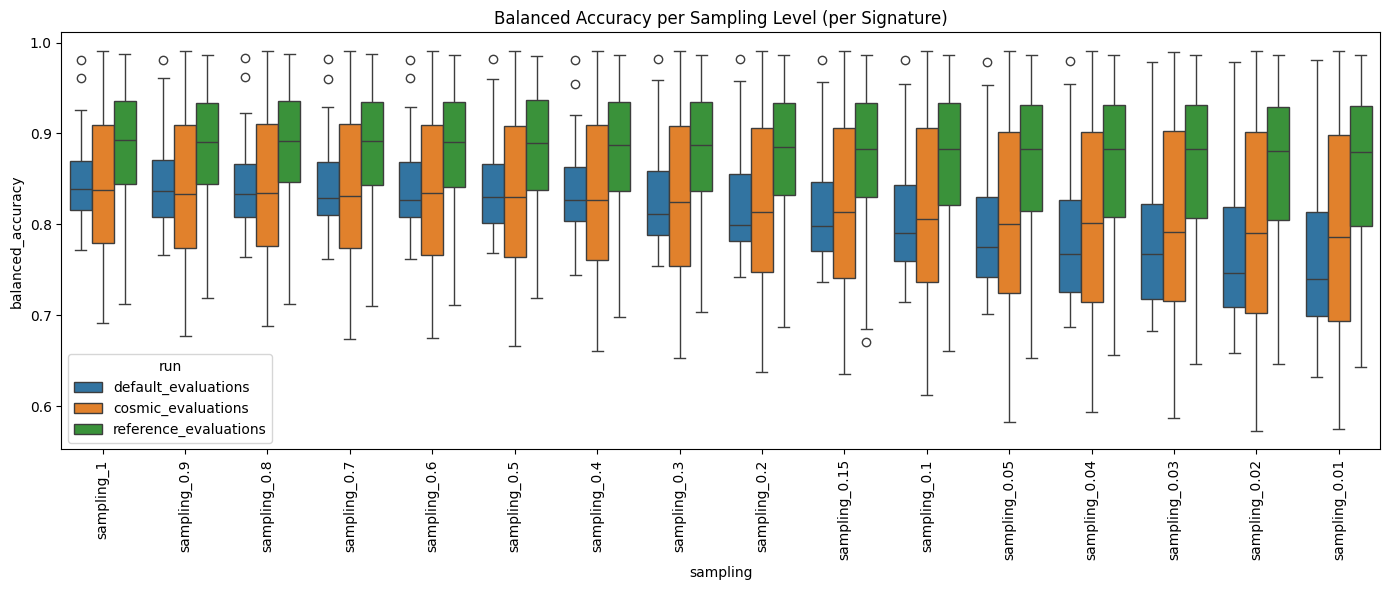

In [18]:
plot_boxplot_accuracy_by_sampling(rss, files)